# Name : Krishna lund
# Cms-id : 023-24-0271
# Section-H
# Github Profile : https://github.com/Krishnalund/telco-customer-churn-eda
# Kaggle Profile : https://www.kaggle.com/krishnalund18
# Dataset :  https://www.kaggle.com/datasets/vedatgul/telco-churn-dataset


# Section 1 : Decision Tree Baseline

In [6]:
# Task-1 Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state).

# Explanation : Loads the cleaned dataset, separates features (X) from the target (y), and converts catergorical data in to numerical values.
# It then splits the data into 80% training and 20% testing using random_state=42 and stratify=y.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("clean_churn.csv")

y = df["Churn"].map({'No': 0, 'Yes': 1})
X = df.drop(columns=["Churn"])
X = pd.get_dummies(X, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5616, 30)
X_test shape: (1405, 30)


In [8]:
# Task-2 Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. 
# This is your benchmark for the rest of the lab.

# Explanation: This code trains the best Decision Tree with max_depth=5, makes predictions on the test data, and calculates Accuracy, Precision, Recall, and F1-score to evaluate its performance.
# The results show 78.7% accuracy, with 65.1% precision, 42.2% recall, and 51.2% F1-score, which will be used as the benchmark for comparing other models.

dt_best = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_best.fit(X_train, y_train)
dt_pred = dt_best.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print(f"Decision Tree (depth=5) — Accuracy: {dt_acc:.3f}, Precision: {dt_prec:.3f}, Recall: {dt_rec:.3f}, F1: {dt_f1:.3f}")

Decision Tree (depth=5) — Accuracy: 0.787, Precision: 0.651, Recall: 0.422, F1: 0.512


# Section 2 : Random Forest

In [9]:
# Task-3 Train a RandomForestClassifier on the same training data (reasonable default n_estimators, e.g. 100–300; fix random_state). Generate predictions on the test set.

# Explanation: A Random Forest classifier with 200 trees was trained using the same training data. random_state=42 ensures reproducible results. 
# The trained model was then used to generate predictions on the test set.

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
# Task-4 In 1–2 sentences, explain in your own words why a Random Forest might generalize better than a single unrestricted Decision Tree.

#Explanation: A Random Forest combines many Decision Trees and averages their predictions, which reduces overfitting and makes the model more stable.
# A single unrestricted Decision Tree can become too complex and memorize the training data, leading to poor performance on unseen data.

# Section 3: Model Evaluation

Accuracy: 0.7743772241992882
Precision: 0.6037735849056604
Recall: 0.43010752688172044
F1 Score: 0.5023547880690737
Confusion Matrix:
 [[928 105]
 [212 160]]


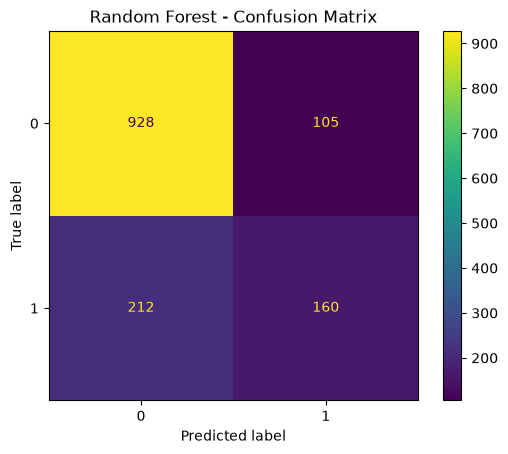

In [10]:
# Task-5 Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

# Explanation: Random Forest achieved 77.4% accuracy, 60.4% precision, 43.0% recall, and 50.2% F1-score. It correctly identified 160 churners but missed 212. 
# Overall, it performed slightly worse than the depth-5 Decision Tree, so it did not clearly improve the results.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:\n", cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Section 4: Decision Tree vs Random Forest

In [11]:
# Task-6 Build a single comparison table: Decision Tree (Part 1) vs. Random Forest (Part 2), across all four metrics.

# Explanation: This code creates a comparison table between the Decision Tree and Random Forest models. It compares their Accuracy, Precision, Recall, 
# and F1-score to see which model performs better.

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_acc, rf_acc],
    "Precision": [dt_prec, rf_prec],
    "Recall": [dt_rec, rf_rec],
    "F1-score": [dt_f1, rf_f1]
})
print(comparison_df)

           Model  Accuracy  Precision    Recall  F1-score
0  Decision Tree  0.787189   0.651452  0.422043  0.512235
1  Random Forest  0.774377   0.603774  0.430108  0.502355


In [ ]:
# Task-7 Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab
# 2/3's finding about class imbalance, which metric matters most here?

# Explanation : The Decision Tree performs slightly better than the Random Forest, with higher Accuracy (78.7% vs 77.4%), Precision (65.1% vs 60.4%), 
# and F1-score (51.2% vs 50.2%). However, the differences are small, so neither model is clearly much better than the other. 
# The Random Forest has a slightly higher Recall (43.0% vs 42.2%). Since the dataset has class imbalance, Recall is important 
# because it shows how many actual churn customers the model can detect. Overall, the Decision Tree is slightly better, 
# but the practical difference between the two models is small.


# Section 5 : Cross-Validation

In [14]:
# Task-8  Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plainaccuracy (e.g. F1-score). 
# Report the mean and standard deviation of each model's fold scores.

# Explanation: This shows that Random Forest performs better during cross-validation, with a higher mean F1-score (0.543 vs. 0.515) and 
# lower standard deviation (0.025 vs. 0.036). Random Forest has better overall F1 performance and is more consistent across different folds, 
# even though the earlier single test-set comparison favored the Decision Tree.

from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(dt_best, X, y, cv=5, scoring='f1')
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='f1')

print(f"Decision Tree CV F1 — mean: {dt_cv_scores.mean():.3f}, std: {dt_cv_scores.std():.3f}")
print(f"Random Forest CV F1 — mean: {rf_cv_scores.mean():.3f}, std: {rf_cv_scores.std():.3f}")

Decision Tree CV F1 — mean: 0.515, std: 0.036
Random Forest CV F1 — mean: 0.543, std: 0.025


In [ ]:
# Task-9 How do the cross-validated results compare to your single train/test split results from Part 3? Do they change
# your view of which model is better, or how confident you are in that conclusion?

# Explanation: The single train/test split showed that the Decision Tree was slightly better, but cross-validation showed that 
# Random Forest had a higher and more consistent F1-score. Therefore, I would prefer Random Forest because its performance was 
# better across multiple data splits.

# Section 6: Hyperparameter Tuning

In [15]:
# Task-10 Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and
# define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination.

# Explanation : GridSearchCV was used to find the best Random Forest hyperparameters. We tuned n_estimators, max_depth, and min_samples_split
# using a small grid and 5-fold cross-validation. It tries all combinations of the hyperparameters, uses 5-fold cross-validation for each
# combination, calculates the F1-score for each, and finds the combination that gives the best F1-score.

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Cont

In [16]:
# Task-11 Report the best hyperparameters found and the corresponding cross-validated score.

# Explanation : GridSearchCV found the best hyperparameters as max_depth = 10, min_samples_split = 5, and n_estimators = 300. 
# These parameters achieved the best cross-validated F1-score of 0.576, showing improved performance during cross-validation.

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", grid_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1 score: 0.576186537595625


In [17]:
# Task-12 Evaluate the tuned model on the held-out test set using the same four metrics as before.

# Explanation:  On the held-out test set, the tuned Random Forest achieved 79.8% accuracy, 66.1% precision, 
# 48.7% recall, and 56.0% F1-score. This outperforms both the default Random Forest (77.4% acc, 50.2% F1) 
# and the depth-5 Decision Tree (78.7% acc, 51.2% F1) on F1-score and recall, confirming that hyperparameter 
# tuning provided a real improvement rather than just added model complexity.

tuned_rf = grid_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Accuracy:", tuned_acc)
print("Precision:", tuned_prec)
print("Recall:", tuned_rec)
print("F1 Score:", tuned_f1)

Accuracy: 0.797864768683274
Precision: 0.6605839416058394
Recall: 0.48655913978494625
F1 Score: 0.5603715170278638


# Section 7 : Final Model Comparison

In [18]:
# Task-13 Build one final comparison table across all models you trained: Decision Tree, default Random Forest, and tuned
# Random Forest — accuracy, precision, recall, F1-score for each.

# Explanation: The Tuned Random Forest performed the best overall, achieving the highest Accuracy (79.8%), Precision (66.1%), Recall (48.7%), 
# and F1-score (56.0%). Hyperparameter tuning improved the Random Forest compared to both the default Random Forest and Decision Tree.

final_comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest (default)", "Random Forest (tuned)"],
    "Accuracy": [dt_acc, rf_acc, tuned_acc],
    "Precision": [dt_prec, rf_prec, tuned_prec],
    "Recall": [dt_rec, rf_rec, tuned_rec],
    "F1-score": [dt_f1, rf_f1, tuned_f1]
})
print(final_comparison_df)

                     Model  Accuracy  Precision    Recall  F1-score
0            Decision Tree  0.787189   0.651452  0.422043  0.512235
1  Random Forest (default)  0.774377   0.603774  0.430108  0.502355
2    Random Forest (tuned)  0.797865   0.660584  0.486559  0.560372


# Section 8 : Feature Importance

Top 5 Important Features:
tenure                         0.183471
TotalCharges                   0.169080
MonthlyCharges                 0.119786
InternetService_Fiber optic    0.075866
Contract_Two year              0.058165
dtype: float64


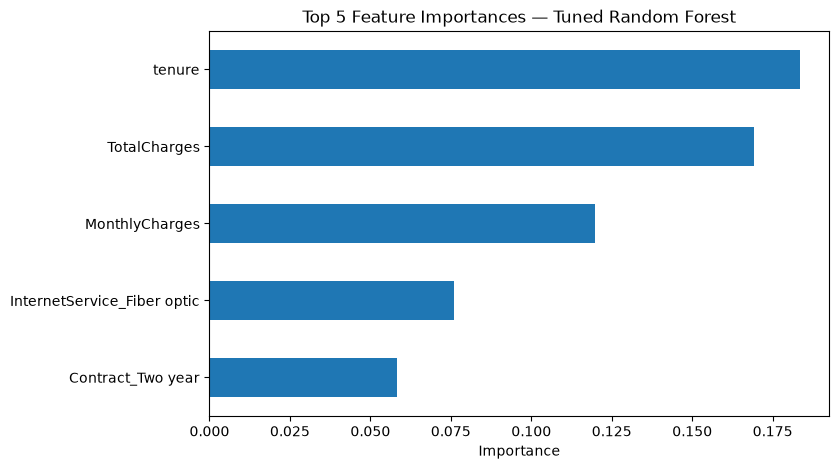

In [19]:
# Task-15 Extract and visualize feature_importances_ for your final model. Which 3–5 features matter most, and do they
# agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

# Explanation: The tuned Random Forest's top 5 features are tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, and Contract_Two year. 
# This largely agrees with the Decision Tree, where tenure and InternetService_Fiber optic were also among the most important features. 
# Overall, both models show that customer tenure, charges, and internet service type are important for predicting churn.

importances = pd.Series(
    tuned_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 Important Features:")
print(importances.head(5))

plt.figure(figsize=(8, 5))
importances.head(5).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 5 Feature Importances — Tuned Random Forest")
plt.show()

# Section 9: Final Model Selection

In [ ]:
# Task-14 Select your final model and justify the choice in 2–3 sentences using evidence from the table above — the best
# training score alone is not sufficient justification.

# Explanation: The Tuned Random Forest is selected as the final model because it achieved the highest Accuracy (79.8%), Precision (66.1%), 
# Recall (48.7%), and F1-score (56.0%) among all three models on the test set. Its higher F1-score and Recall show that it provides 
# better overall performance and is better at identifying churn customers.

# Section 10: Kaggle Prediction/Submission

In [22]:
# Task-16 Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and
# assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv.

# Explanation: A submission dataframe was created using the tuned Random Forest's predictions on the test set, with the test set's row index 
# as a stand-in customer identifier (since customerID wasn't in clean_churn.csv), and saved as submission.csv with churn labels mapped back to "Yes"/"No".

submission_df = pd.DataFrame({
    "customerID": X_test.index,
    "Churn": tuned_pred
})
submission_df["Churn"] = submission_df["Churn"].map({0: "No", 1: "Yes"})
submission_df.to_csv("submission.csv", index=False)
submission_df.head()

,customerID,Churn
0,5615,Yes
1,6112,No
2,2356,No
3,2196,No
4,832,No


In [23]:
print(submission_df.shape)  
print(submission_df["Churn"].value_counts())

(1405, 2)
Churn
No     1131
Yes     274
Name: count, dtype: int64


# Section-11 Conclusion

In [ ]:
# Task-17 Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your
# Lab 3 Decision Tree, and what are its remaining limitations?

# Explanation: I finally chose the tuned Random Forest because it performed better than the other models. 
# It achieved 79.8% accuracy and 56.0% F1-score, which is better than my Lab 3 Decision Tree with 78.7% accuracy and 51.2% F1-score. 
# Cross-validation also showed that the Random Forest gave more reliable results than the Decision Tree. However, its main limitation is that 
# its recall is below 50%, meaning it still misses almost half of the customers who are likely to leave. 
# The most important features were tenure, charges, and internet service type.


In [ ]:
# Task-18 What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? 
# Describe it — do not implement it here.

# Explanation: If I had more time, I would first handle the class imbalance using methods like class_weight='balanced'
# so the model can detect more customers who may leave. I would also try other algorithms such as Gradient Boosting or XGBoost to see 
# if they perform better than Random Forest. I would do more hyperparameter tuning by testing a wider range of settings. 
# I would also create new features, such as TenureGroup and AverageMonthlySpend, to find patterns that the current features may not capture. 
# These changes could improve the model's ability to identify customers who are likely to churn.
